# Notebook 1 - Data Cleaning & Transforming

Objectif:

- Préparer les données pour permettre une analyse fiable.

Actions :

- Import des données

- Nettoyage

- Contrôles qualité

- Création des tables finales (dim_*, fact_sales, fact_sales_order)

- Export des datasets propres

____________

## Sommaire 

0. Introduction
1. Importation des librairies et données
2. Préparation des données
3. Transformation des données
4. Conclusion
5. Compétences mobilisées


_________

## 0. Introduction

Ce projet fait partie de ma candidature à la formation Data Analyst proposée par OpenClassrooms, et financée par France Travail, et s'inscrit dans le cadre de mon projet de reconversion professionnelle, accompagné et validé par un conseiller France Travail.

Le dataset utilisé dans ce projet contient le registre des transactions d'une entreprise fictive dans le secteur de la vente au détail.

L'objectif est d'identifier des dynamiques commerciales et des comportements clients afin de produire des insights exploitables pour la prise de décision.

Cette étude sera divisée en deux étapes: 

* La première partie (Notebook 1) sera dédiée au nettoyage et transformation des données, afin de les préparer pour l'analyse et d'éviter les anomalies ou les résultats biaisés.

* La deuxième partie (Notebook 2) se concentrera sur l'analyse exploratoire de ces données nettoyées et sur la compréhension des enjeux business à partir de l'identification des indicateurs clés de performance de l'entreprise: distribution du chiffre d'affaires, tendances mensuelles au fil des années, mesures de dispersion et de concentration. Cette étape permettra de définir une stratégie d'analyse et de répondre à des problématiques métier structurelles, avec l'identification d'actions potentielles.  

Remarques: 
Les données ont été enregistrées en anglais. Par souci de cohérence, les variables et veleurs resteront en anglais; néanmoins, les résultats et interprétations seront communiqués en français. 

Les tables sont en format CSV (Comma-separated values ou valeurs séparées par virgule) et seront exploitées en Python dans un environnement Jupyter Notebook.

__________

## Présentation du Notebook 1 - Data Cleaning & Transforming

Objectif :

L’objectif de cette première partie du projet est de préparer le dataset afin d'obtenir des données fiables pour l'analyse.

Elle consistera à nettoyer et transformer les quatre tables qui composent ce jeu de données : Orders, Customers, Products, Stores

Méthodologie : 

* Contrôle de la qualité des données : gestion des valeurs manquantes et des doublons, validation des types, vérification de la granularité.

* Standardisation des formats : dates, codes, libellés.

* Inspection des variables numériques et catégorielles : dispersion, proportions, relations entre variables.

* Vérification de la cohérence entre les tables : gestion des clés primaires et étrangères, alignement des identifiants pour modélisation relationnelle.

* Préparation des données pour l’analyse statistique et la visualisation.

_______

## 1. Importation des librairies et données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

In [2]:
#Import et chargement des données dans un dataframe
df_customers_raw = pd.read_csv('../data/raw/Customers.csv', parse_dates=['Birth_Date'])
df_orders_raw = pd.read_csv('../data/raw/Orders.csv', parse_dates=['Order_Date'])
df_products_raw = pd.read_csv('../data/raw/Products.csv')
df_stores_raw = pd.read_csv('../data/raw/Stores.csv')

In [3]:
#Faire une copie de la table avant de modifier les données brutes
df_customers = df_customers_raw.copy()
df_orders = df_orders_raw.copy()
df_products = df_products_raw.copy()
df_stores = df_stores_raw.copy()

__________

## 2. Préparation des données

### 2.1 Table Customers

**Description** : La table Customers est une table de dimension contenant les informations descriptives des clients (identifiant, contact et données démographiques).

Elle comprend initialement 5 020 enregistrements et 6 colonnes.

**Granularité** : Chaque ligne représente un client unique.

**Clé primaire** : La clé primaire est Customer_ID.

**Variables** : Customer_ID, First_Name, Last_Name, Email, Gender, Birth_Date

**Cette table permet** :

* L’analyse démographique (genre, âge, tranche d’âge)
* La segmentation client
* Le ciblage marketing (email)
* Le croisement avec les tables transactionnelles pour analyser la performance par profil client

In [4]:
df_customers.head()

,Customer_ID,First_Name,Last_Name,Email,Gender,Birth_Date
0,1,Joel,Thompson,wadeelizabeth@example.com,F,1952-10-17
1,2,Nicole,Butler,kellyjose@example.net,M,1968-04-27
2,3,Joshua,Leblanc,danielssamantha@example.com,F,1954-10-17
3,4,Melissa,Hardy,troy32@example.org,F,2005-08-25
4,5,Paul,Smith,elliottlauren@example.com,F,2001-03-29


#### 2.1.1 Inspection initiale de la table 

In [5]:
#Vérifier la forme et data types
shape_init = df_customers.shape
print(f'Cette table comporte initialement {shape_init[0]} enregistrements répartis sur {shape_init[1]} colonnes')
print(f'Data types:\n{df_customers.dtypes}')

Cette table comporte initialement 5020 enregistrements répartis sur 6 colonnes
Data types:
Customer_ID             int64
First_Name             object
Last_Name              object
Email                  object
Gender                 object
Birth_Date     datetime64[ns]
dtype: object


In [6]:
#Vérifier l'unicité de la clé primaire Customer_ID
df_customers['Customer_ID'].is_unique

False

In [7]:
#Vérifier les doublons
df_customers['Customer_ID'].duplicated().sum()

np.int64(20)

In [8]:
#Vérifier les valeurs manquantes
df_customers.isnull().sum()

Customer_ID     0
First_Name      0
Last_Name       0
Email          51
Gender          0
Birth_Date      0
dtype: int64

In [9]:
#Informations génériques
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5020 entries, 0 to 5019
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Customer_ID  5020 non-null   int64         
 1   First_Name   5020 non-null   object        
 2   Last_Name    5020 non-null   object        
 3   Email        4969 non-null   object        
 4   Gender       5020 non-null   object        
 5   Birth_Date   5020 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(1), object(4)
memory usage: 235.4+ KB


*Résultats de l'inspection*:
* 5 020 lignes, 6 colonnes
* Types cohérents (Birth_Date en datetime, variables categoriques en object, clé primaire en int)
* 51 valeurs manquantes sur Email (~1% du total)
* 20 doublons détectés sur Customer_ID

________

#### 2.1.2 Audit Qualité

**Problèmes identifiés**

1. La clé primaire n’est pas unique (20 doublons).
2. 50 emails manquants.
3. Absence de standardisation des variables texte.
4. Aucune variable démographique dérivée (âge).



__________

#### 2.1.3 Nettoyage 

**1. Doublons sur Customer_ID**

Constat :
20 doublons détectés.

Action :
Suppression des lignes dupliquées.

Justification :
Une table dimension doit garantir l’unicité de la clé primaire pour assurer l’intégrité des jointures futures.

Résultat :
5 000 clients uniques conservés.

In [10]:
# localiser les doublons
df_customers.loc[df_customers['Customer_ID'].duplicated(keep=False)].head()

,Customer_ID,First_Name,Last_Name,Email,Gender,Birth_Date
182,183,Tina,Hayden,kwolfe@example.net,F,1965-06-09
1097,1098,Ethan,Howard,geoffreyjones@example.net,M,2003-03-06
1161,1162,Heather,Charles,xhughes@example.com,F,1955-06-01
1291,1292,Charles,Davis,tina26@example.net,F,1964-02-16
1422,1423,Andrea,Walker,stephensjade@example.com,M,1968-08-13


In [11]:
# vérification rapide avant supprimer les doublons
df_customers[df_customers['Customer_ID'] == 1990]

,Customer_ID,First_Name,Last_Name,Email,Gender,Birth_Date
1989,1990,Nancy,Clark,carla96@example.com,M,1991-08-12
5006,1990,Nancy,Clark,carla96@example.com,M,1991-08-12


In [12]:
#supprimer les doublons
df_customers.drop_duplicates(inplace=True, ignore_index=True)

In [13]:
#vérifier
df_customers[df_customers['Customer_ID'] == 1990]

,Customer_ID,First_Name,Last_Name,Email,Gender,Birth_Date
1989,1990,Nancy,Clark,carla96@example.com,M,1991-08-12


_______

**2. Valeurs manquantes – Email**

Constat :
50 valeurs manquantes (~1%).

Action :
Remplacement par la valeur "Unknown".

Justification :
Préserver les enregistrements clients tout en identifiant les cas non exploitables pour des actions marketing.

In [14]:
#localiser les valeurs manquantes
df_customers['Email'].isnull().sum()

np.int64(50)

In [15]:
# substituer les emails manquants par 'Unknown'= unconnu
df_customers['Email'] = df_customers['Email'].fillna('Unknown')
df_customers['Email'].isnull().sum()

np.int64(0)

__________

**3. Standardisation des colonnes texte**

Action :

Suppression des espaces superflus

Uniformisation du format (Title case pour noms, lower case pour email)

Justification :
Éviter les incohérences lors d’analyses futures (ex : segmentation, matching).

In [16]:
#inspection variables first_name, last_name
print("First name lengths:\n", df_customers['First_Name'].dropna().str.len().describe())

First name lengths:
 count    5000.000000
mean        6.051000
std         1.498282
min         3.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        11.000000
Name: First_Name, dtype: float64


In [17]:
print("Last name lengths:\n", df_customers['Last_Name'].dropna().str.len().describe())

Last name lengths:
 count    5000.000000
mean        6.091800
std         1.459657
min         2.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        11.000000
Name: Last_Name, dtype: float64


In [18]:
#nettoyer variable prénom 'first_name' et nom 'last_name
df_customers['First_Name'] = df_customers['First_Name'].str.strip().str.title()
df_customers['Last_Name'] = df_customers['Last_Name'].str.strip().str.title()

In [19]:
#standardiser la variable 'email'
df_customers['Email'] = df_customers['Email'].str.strip().str.lower()

In [20]:
#doit contenir '@' et '.'
email_invalide = df_customers[
    (df_customers['Email'] != 'unknown') &
    (
~df_customers['Email'].str.contains('@', na=False) |
~df_customers['Email'].str.contains('.', na=False)
    )
]
email_invalide

,Customer_ID,First_Name,Last_Name,Email,Gender,Birth_Date


_________

**4. Vérification de la variable Gender**

Résultat :
Deux modalités uniquement (M / F).
Distribution équilibrée.

Aucune correction nécessaire.

In [21]:
# inspections variable genre
df_customers['Gender'].unique()
df_customers['Gender'].value_counts()

Gender
M    2555
F    2445
Name: count, dtype: int64

___________

#### 2.1.4 Feature engineering 

**1. Création de Full_Name**

Objectif :
Faciliter la lisibilité et l’usage marketing.

In [22]:
#variable full_name
df_customers['Full_Name'] = df_customers['First_Name'] + ' ' + df_customers['Last_Name']

_________

**2. Création de la variable Age**

Objectif :
Permettre une analyse démographique dynamique basée sur la date de naissance.

In [23]:
#Variable Age
today = pd.Timestamp.today().normalize()

df_customers['Age'] = (
    today.year - df_customers['Birth_Date'].dt.year
    - (
        (today.month < df_customers['Birth_Date'].dt.month) |
        (
            (today.month == df_customers['Birth_Date'].dt.month) &
            (today.day < df_customers['Birth_Date'].dt.day)
        )
    ).astype(int)
)

In [24]:
#Inspection de la Variable Age
df_customers['Age'].describe()

count    5000.000000
mean       49.297000
std        18.268572
min        18.000000
25%        33.000000
50%        50.000000
75%        65.000000
max        81.000000
Name: Age, dtype: float64

**Résultat** 
* Âge moyen : 49 ans
* Distribution cohérente (18 à 80 ans).

___________

**3. Création de Age_Group**

Objectif :
Faciliter la segmentation et l’analyse comparative entre générations.

Tranches définies :
18–24, 25–34, 35–49, 50–64, 65+

In [25]:
#Variable Age_Group
bins = [18, 25, 35, 50, 65, 81]
labels = ['18-24', '25-34', '35-49', '50-64', '65+']
df_customers['Age_Group'] = pd.cut(df_customers['Age'], bins=bins, labels=labels, right=False)

_________

#### 2.1.5 Validation finale

5 000 clients uniques

Clé primaire garantie

Aucune valeur manquante critique

Variables démographiques prêtes pour analyse

Dataset structuré pour jointure avec les tables transactionnelles

La table est conforme pour une analyse fiable.

In [26]:
#table nettoyée et nouvelle table enregistrée

df_customers_cleaned = (
    df_customers[[
        'Customer_ID', 
        'First_Name', 
        'Last_Name', 
        'Full_Name',
        'Email', 
        'Gender',
        'Birth_Date', 
        'Age', 
        'Age_Group'
        ]]
)

shape_end = df_customers_cleaned.shape
pct_removed = ((shape_init[0]-shape_end[0])/shape_init[0])*100
print(f"Cette table comporte désormais {shape_end[0]} enregistements répartis sur {shape_end[1]} colonnes\n{pct_removed:.2f}% des lignes ont été supprimées")

df_customers_cleaned.to_csv('../data/cleaned/dim_customers.csv', index=False)
print("Dataset prêt pour analyse")

Cette table comporte désormais 5000 enregistements répartis sur 9 colonnes
0.40% des lignes ont été supprimées
Dataset prêt pour analyse


____________

### 2.2 Table Orders

**Description** : La table Orders est une table de faits transactionnelle contenant les ventes par produit. Elle constitue la table centrale du modèle analytique. Elle relie les dimensions Clients, Produits et Stores et permet le calcul des indicateurs de performance (volume, revenu, retours, comportement d’achat).

**Granularité** : Chaque ligne représente un produit par commande

**Clé primaire logique** : La clé primaire est Order_ID et Product_ID

**Clés étrangères** : Les clés étrangères sont Customer_ID, Product_ID, Store_ID

**Mesures** : Variables Quantity et Discount

**Dimensions Temporelles**: Variable Order_Date

**Attributs Comportementaux** : Variables Payment_Method et Return_Flag

**Remarques** : Le montant total des ventes n'est pas présent. Il devra être calculé ultérieurement via jointure avec la table Products (Price × Quantity × (1 - Discount)).

In [27]:
df_orders.head()

,Order_ID,Customer_ID,Product_ID,Store_ID,Order_Date,Quantity,Discount,Payment_Method,Return_Flag
0,1,584,28,7,2024-05-11 16:12:01,1,0.2,PayPal,0
1,1,584,85,7,2024-05-11 16:12:01,5,0.0,PayPal,0
2,1,584,99,7,2024-05-11 16:12:01,20,0.0,PayPal,0
3,1,584,60,7,2024-05-11 16:12:01,1,0.0,PayPal,0
4,2,3343,45,3,2025-12-25 04:13:29,1,0.0,PayPal,0


#### 2.2.1 Inspection initiale de la table 

In [28]:
#Vérifier la forme et data types
shape_init = df_orders.shape
print(f'Cette table comporte initialement {shape_init[0]} enregistrements sur {shape_init[1]} colonnes')
print(f'Data types:\n{df_orders.dtypes}')


Cette table comporte initialement 36180 enregistrements sur 9 colonnes
Data types:
Order_ID                   int64
Customer_ID                int64
Product_ID                 int64
Store_ID                   int64
Order_Date        datetime64[ns]
Quantity                   int64
Discount                 float64
Payment_Method            object
Return_Flag                int64
dtype: object


In [29]:
#Vérifier l'unicité de Order_ID
df_orders['Order_ID'].is_unique

False

In [30]:
#Vérifier l'unicité de Product_ID
df_orders['Product_ID'].is_unique

False

In [31]:
#Vérifier les doublons
df_orders[['Order_ID', 'Customer_ID','Product_ID', 'Store_ID']].duplicated().sum()

np.int64(396)

In [32]:
#Vérifier les valeurs manquantes
df_orders.isnull().sum()

Order_ID             0
Customer_ID          0
Product_ID           0
Store_ID             0
Order_Date           0
Quantity             0
Discount          1831
Payment_Method       0
Return_Flag          0
dtype: int64

In [33]:
#informations génériques
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36180 entries, 0 to 36179
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order_ID        36180 non-null  int64         
 1   Customer_ID     36180 non-null  int64         
 2   Product_ID      36180 non-null  int64         
 3   Store_ID        36180 non-null  int64         
 4   Order_Date      36180 non-null  datetime64[ns]
 5   Quantity        36180 non-null  int64         
 6   Discount        34349 non-null  float64       
 7   Payment_Method  36180 non-null  object        
 8   Return_Flag     36180 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(6), object(1)
memory usage: 2.5+ MB


**Résultats de l'inspection**
* 36180 registres, 9 colonnes
* Types cohérents (Order_Date en datetime, variables catégorielles en object, variables numériques en int/float)
* 1831 valeurs manquantes sur 'Discount' (~5% du total/faible proportion)
* 396 doublons détectés sur Order_ID, Product_ID

_________

#### 2.2.2 Audit Qualité
**Points critiques identifiés**
1. Non-unicité de la clé primaire logique
2. Valeurs manquantes sur Discount
3. Vérification des variables numériques (Quantity) 
4. Vérifier les variables catégorielles Payment_Method et Return_Flag
5. Contrôle d’intégrité des clés étrangères
6. Analyser de la cohérence temporelle

_____________

#### 2.2.3 Nettoyage

**1. Doublons sur Order_ID/Product_ID**

Constat: 396 lignes dupliquées sur la combination transactionnelle

Analyse: 

Certaines lignes avaient même Order_ID et Product_ID mais des quantités ou remises différentes.

Dans une table fact, caque ligne doit représenter une transaction unique

Action: 

Agrèger des lignes dupliquées par Order_ID, Product_ID afin d'éviter la suppression de lignes d'achat fractionnées.

Justification:

Assurer l'intégrité des agrégations futures (CA, volume, panier moyen)

Résultat :

35784 transactions uniques conservées.
Unicité garantie


In [34]:
#localiser les doublons
df_orders.loc[df_orders[['Order_ID', 'Product_ID', 'Customer_ID', 'Store_ID']].duplicated(keep=False)]

,Order_ID,Customer_ID,Product_ID,Store_ID,Order_Date,Quantity,Discount,Payment_Method,Return_Flag
68,23,468,64,7,2024-07-05 15:40:25,1,0.00,Card,0
70,23,468,64,7,2024-07-05 15:40:25,2,0.05,Card,0
163,55,433,79,10,2025-09-30 14:28:52,3,0.10,Card,0
165,55,433,79,10,2025-09-30 14:28:52,1,0.10,Card,0
287,99,2001,27,8,2025-01-22 21:25:56,1,0.20,Cash,0
...,...,...,...,...,...,...,...,...,...
35958,11928,1111,30,1,2025-06-17 14:13:50,3,0.05,Card,0
36011,11947,4972,64,1,2023-03-16 00:38:05,1,0.00,PayPal,0
36013,11947,4972,64,1,2023-03-16 00:38:05,2,0.05,PayPal,0
36158,11994,1732,76,8,2018-08-17 02:02:44,10,0.00,Cash,0


In [35]:
# vérification rapide avant de supprimer les doublons
df_orders.loc[(df_orders['Order_ID']== 11947) & (df_orders['Product_ID']== 64)]

,Order_ID,Customer_ID,Product_ID,Store_ID,Order_Date,Quantity,Discount,Payment_Method,Return_Flag
36011,11947,4972,64,1,2023-03-16 00:38:05,1,0.00,PayPal,0
36013,11947,4972,64,1,2023-03-16 00:38:05,2,0.05,PayPal,0


Bien que des doublons ont été identifiés sur la combinaison Order_ID, Product_ID, après cette vérification nous pouvons observer que quelques lignes présentent des différences de quantité ou de remise. Ce qui peut signifier des fractionnements de ligne au sein d'une même commande.

**Solution** : Agréger la Quantity et Discount par Order_ID et Product_ID

In [36]:
#Agrégation
df_orders = (
    df_orders
    .groupby([
        'Order_ID',
        'Product_ID',
        'Customer_ID',
        'Store_ID',
        'Order_Date',
        'Payment_Method',
        'Return_Flag'], 
        as_index=False)
    .agg({
        'Quantity':'sum',
        'Discount':'max'
    })
)
df_orders = (
    df_orders[[
        'Order_ID',
        'Customer_ID',
        'Product_ID',
        'Store_ID',
        'Order_Date', 
        'Quantity', 
        'Discount',
        'Payment_Method',
        'Return_Flag'
        ]]
)

In [37]:
#Vérifier
print(f"{df_orders.shape}")
print(f"Lignes identiques: {df_orders[['Order_ID', 'Product_ID', 'Customer_ID', 'Store_ID']].duplicated().sum()}")

(35784, 9)
Lignes identiques: 0


__________

**2. Valeurs Manquantes - Varible Discount**

Constat :
~5% de valeurs manquantes

Interprétation :
Absence probable de remise appliquée.

Action :
Remplacement par "0.00".

Justification :
Éviter des erreus lors du calcul du montant total.

In [38]:
#Valeurs manquants dans la colonne Discount
df_orders['Discount'] = df_orders['Discount'].fillna(0.00).astype('float64')

In [39]:
#Validation
df_orders['Discount'].isna().sum()

np.int64(0)

________

**3. Variable Quantity**

Objectif:

Observer la distribuition des volumes de ventes

In [40]:
#Analyse de la distribution de la variable
df_orders['Quantity'].agg(['min', 'mean','median','max'])

min        1.000000
mean       3.219148
median     2.000000
max       40.000000
Name: Quantity, dtype: float64

Min = 1 | Médiane = 1 | Moyenne ≈ 3,18 | Max = 20

**Interprétation** :

* Majorité des achats unitaires
* Quelques achats en volume élevé
* Pas d’anomalies (pas de quantité négative ou nulle)

**Analyse du volume par panier**

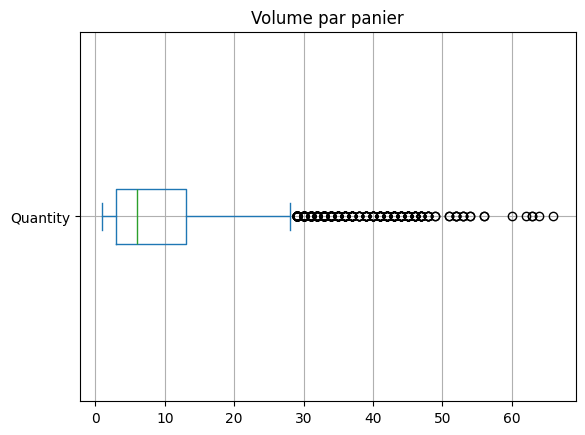

In [41]:
df_orders.groupby('Order_ID').agg({
    'Quantity': 'sum'
}).plot(kind='box', vert=False, grid=True)

plt.title('Volume par panier')
plt.show()

**Interprétation**: 
* Distribution concentrée entre 1 et 25 unités
* Présence d’outliers (> 50 unités)

**Conclusion** :
Distribution réaliste. Aucune correction nécessaire.

_________

**4. Variable Payment_Method**

Objectif:

Analyser la proportion entre chaque modalité de payement 

Modalités:

* Card (~33%)
* PayPal (~33%)
* Cash (~34%)

Distribution équilibrée. 

Aucune incohérence détectée.

Intérêt analytique :

Permet d’analyser les préférences de paiement et leur lien avec le panier moyen ou les retours.

In [42]:
effectif = df_orders['Payment_Method'].value_counts()
frequence = df_orders['Payment_Method'].value_counts(normalize=True)*100
modalites = effectif.index

df_payement_method = pd.DataFrame(modalites, columns=['Payment_Method'])
df_payement_method['Nb_Total'] = effectif.values
df_payement_method['Proportion %'] = frequence.values.round(2)
df_payement_method


,Payment_Method,Nb_Total,Proportion %
0,Cash,12291,34.35
1,Card,11753,32.84
2,PayPal,11740,32.81


_______

**5. Variable Return_Flag**

Objectif:

Analyser la proportion de retours

Variable Boolènne 
* 0 (pas de retour) ~95%
* 1 (retour effectué) ~5%

Distribution cohérente.

Intérêt analytique :

Permet d’identifier les produits ou catégories générant plus de retours.  

In [43]:
#proportion de retours
proportion = df_orders['Return_Flag'].value_counts(normalize=True)*100
print(f'Percentage Retours(%)\n{proportion}')

Percentage Retours(%)
Return_Flag
0    94.897161
1     5.102839
Name: proportion, dtype: float64


________

#### 2.2.3 Audit des Clés étrangères
Objectif: 

Vérification de la cohérence référentielle

**1. Customer_ID**

Objectif: 

Vérifier si les Customer_ID correspondent à la table Customers

Aucune incohérence détectée.

In [44]:
set(df_orders['Customer_ID']) - set(df_customers['Customer_ID'])

set()

_______

**2. Product_ID**

Objectif:

Vérifier si les Produit_ID correspondent à la table Products

Aucune incohérence détectée.

In [45]:
set(df_orders['Product_ID']) - set(df_products['Product_ID'])

set()

_______

**3. Store_ID**

Objectif:

Vérifier si les Store_ID correspondent à la table Stores

Aucune incohérence détectée.

In [46]:
set(df_orders['Store_ID']) - set(df_stores['Store_ID'])

set()

**Conclusion** :
Intégrité relationnelle garantie.

___________

#### 2.2.4 Analyse des Dates

Période couverte:

* Min: 29/02/2016
* Max: 23/02/2026

Couverture de 10 ans.

In [47]:
df_orders['Order_Date'].agg({'Min': 'min', 'Max': 'max'})

Min   2016-02-29 14:19:14
Max   2026-02-23 11:06:35
Name: Order_Date, dtype: datetime64[ns]

**Conclusion** : Les variables des composantes temporelles seront crées ultérieurement dans la table calculée.

______________

#### 2.2.5 Validation finale

35 784 transactions propres

Clé primaire logique garantie

Valeurs manquantes traitées

Intégrité référentielle validée

Table prête pour :

* Calcul du chiffre d’affaires
* Analyse panier moyen
* Analyse client
* Analyse produit
* Analyse géographique
* Analyse temporelle

In [48]:
#table nettoyée et nouvelle table enregistrée

df_orders_cleaned = df_orders

shape_end = df_orders_cleaned.shape
pct_removed = ((shape_init[0]-shape_end[0])/shape_init[0])*100

print(f"Cette table comporte désormais {shape_end[0]} enregistements répartis sur {shape_end[1]} colonnes\n{pct_removed:.2f}% des lignes ont été supprimées")

df_orders_cleaned.to_csv('../data/cleaned/fact_orders.csv', index=False)

print("Dataset prêt pour transformation")

Cette table comporte désormais 35784 enregistements répartis sur 9 colonnes
1.09% des lignes ont été supprimées
Dataset prêt pour transformation


_________

### 2.3 Table Products
**Description** : La table Products est une table de dimension contenant les informations descriptives des produits (identifiant, nom, catégorie et sous-catégorie et prix).

Elle comprend initialement 100 enregistrements et 5 colonnes.

**Granularité** : Chaque ligne représente un produit unique

**Clé primaire** : La clé primaire est Product_ID

**Usage analytique** : 

Cette table permet:
* L’analyse de la performance commerciale *par produit
* L’analyse par catégorie et sous-catégorie
* L’étude de la structure des prix
* Les jointures avec les tables transactionnelles pour mesurer chiffre d’affaires, volumes et rentabilité


In [49]:
df_products.head()

,Product_ID,Product_Name,Category,Subcategory,Price
0,1,Decide 24,Toys,Doll,59.94
1,2,Four 14,Books,Non-fiction,52.00
2,3,Follow 36,Toys,Board Game,60.29
3,4,Phone 40,Toys,Puzzle,36.78
4,5,Building 25,Electronics,Headphones,139.84


#### 2.3.1 Inspection initiale de la table 

In [50]:
#Vérifier la forme et data types
shape_init = df_products.shape
print(f'Cette table comporte initialement {shape_init[0]} enregistrements répartis sur {shape_init[1]} colonnes')
print(f'Data types:\n{df_products.dtypes}')

Cette table comporte initialement 100 enregistrements répartis sur 5 colonnes
Data types:
Product_ID        int64
Product_Name     object
Category         object
Subcategory      object
Price           float64
dtype: object


In [51]:
#Vérifier l'unicité de la clé primaire Product_ID
df_products['Product_ID'].is_unique

True

In [52]:
#Vérifier les doublons
df_products['Product_Name'].duplicated().sum()

np.int64(0)

In [53]:
#Vérifier si valeus manquantes
df_products.isnull().sum()

Product_ID      0
Product_Name    0
Category        0
Subcategory     0
Price           0
dtype: int64

In [54]:
#Informations génériques
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Product_ID    100 non-null    int64  
 1   Product_Name  100 non-null    object 
 2   Category      100 non-null    object 
 3   Subcategory   100 non-null    object 
 4   Price         100 non-null    float64
dtypes: float64(1), int64(1), object(3)
memory usage: 4.0+ KB


**Résultat de l'inspection**:
* 100 lignes, 5 colonnes
* La clé primaire est unique
* Chaque produit a un nom unique
* Aucun doublon détecté
* Aucune valeur manquante détectée
* Type cohérents (variables categoriques en object, variable numérique en float, clé primaire en int)

_________

#### 2.3.2 Audit Qualité
**Points de contrôle**
1. Absence de standardisation des variables texte.
2. Cohérence entre Category et Subcategory
3. Distribution et cohérence des prix

_________

#### 2.3.3 Nettoyage

**1. Standardisation des colonnes texte**

Action :

Suppression des espaces superflus

Uniformisation du format (Title case)

Justification :
Prévenir les incohérences lors des regroupements analytiques (groupby, jointures).

In [55]:
#standardiser les colonnes de texte (strings)
df_products['Product_Name'] = df_products['Product_Name'].str.strip().str.title()
df_products['Category'] = df_products['Category'].str.strip().str.title()
df_products['Subcategory'] = df_products['Subcategory'].str.strip().str.title()

**2. Vérification de la variable Category et Subcategory**

Résultat :

5 catégories principales
3 sous-catégories par catégorie
Cohérence logique entre les deux niveaux

Aucune correction nécessaire.

Cette structure hiérarchique permettra une analyse multi-niveau (macro : catégorie / micro : sous-catégorie).

In [56]:
df_products[['Category', 'Subcategory']].value_counts().sort_index()

Category     Subcategory
Books        Comics          3
             Fiction         6
             Non-Fiction     8
Clothing     Jacket          7
             Pants           7
             T-Shirt         8
Electronics  Headphones     10
             Laptop          4
             Phone           5
Home         Chair           8
             Lamp            8
             Table           6
Toys         Board Game      8
             Doll            8
             Puzzle          4
Name: count, dtype: int64

__________

#### 2.3.4 Analyse exploratoire de la variable Price

**1. Distribution générale**


In [57]:
df_products['Price'].describe()

count     100.000000
mean      147.661700
std       221.962445
min         6.720000
25%        34.062500
50%        55.750000
75%       148.527500
max      1067.940000
Name: Price, dtype: float64

**Résultats**

Prix minimum : 6.72

Prix maximum : 1 067.94

Moyenne : 147.66

Médiane : 55.75

Constat :
Distribution fortement asymétrique (skewed), avec une dispersion importante entre produits d’entrée de gamme et produits premium (notamment Laptop et Phone).

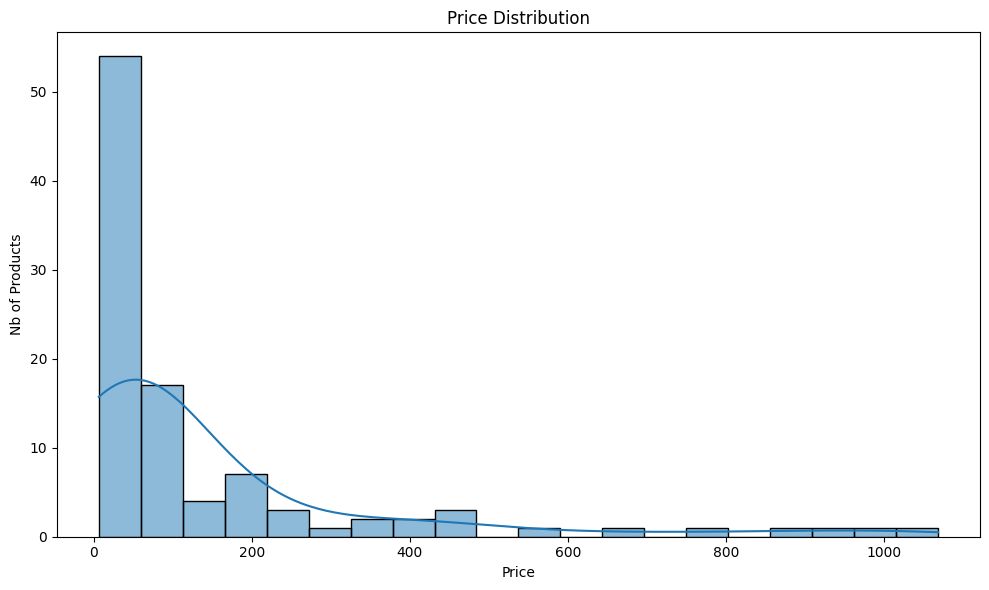

In [58]:
#Histogramme des prix
#Comment les prix sont distribués
plt.figure(figsize=(10,6))
sns.histplot(df_products['Price'], bins=20, kde=True)
plt.title('Price Distribution')
plt.ylabel('Nb of Products')
plt.tight_layout()
plt.show()

**Résultat**: 
* Beaucoup de produits à bas prix
* Quelques produits très chers = distribution asymétrique (skewed)

**Conclusion analytique** :

La moyenne globale n’est pas représentative.

_________

**2. Variation de prix par sous-catégorie**

In [59]:
subcat_var_price = (
    df_products
    .groupby(['Category','Subcategory'])['Price']
    .agg([
        'min',
        'max',
        'median',
        'mean'])
).round(2)

subcat_var_price.sort_values('max', ascending=False)


min      max  median    mean
Category    Subcategory                                 
Electronics Laptop       251.17  1067.94  779.86  719.71
            Phone        477.11   930.98  759.44  737.63
Home        Table        166.01   482.28  306.02  325.48
            Chair         55.58   397.58  229.93  228.05
Electronics Headphones    59.34   190.96  122.82  127.95
Clothing    Jacket        36.96   180.22   97.02  103.97
Home        Lamp          33.98   118.27   45.29   67.20
Clothing    Pants         18.27    69.31   55.47   47.17
Toys        Board Game    24.07    66.27   50.52   49.82
            Doll          11.27    59.94   34.28   35.99
            Puzzle        36.78    55.92   38.74   42.54
Books       Non-Fiction   18.59    52.00   30.81   33.42
Clothing    T-Shirt       10.81    46.74   31.39   29.48
Books       Fiction        6.72    44.14   15.86   20.71
            Comics        13.06    29.55   20.09   20.90

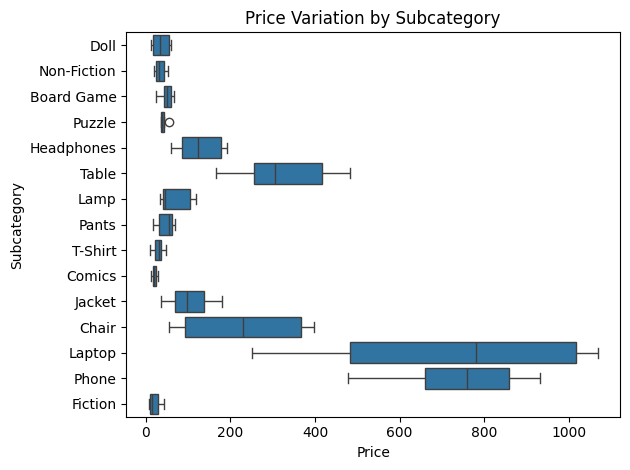

In [60]:
#Différences de prix selon les sous-catégories
sns.boxplot(x='Price', y='Subcategory', data=df_products)
plt.title('Price Variation by Subcategory')
plt.tight_layout()
plt.show()

**Résultat**:
* Laptop et Phone (Electronics) présentent les prix les plus élevés (gamme premium)
* Comics / Fiction (Books et Toys) - présentent des prix bas (gamme basse)
* Table / Chair (Home) - positionnés en milieu/haut de gamme (intermédiaire)

**Conclusion analytique** :
La forte asymétrie de la distribution suggère que les analyses futures devront être segmentées par catégorie afin d’éviter un biais lié aux produits premium.

__________

#### 2.3.5 Feature engineering 

**1. Création de Price_Buckets**

Objectif :
* Segmentation des produits par tranche selon le prix global en quatre catégories (Low, Mid, High, Premium)
* Identifier l’effet des produits premium sur le revenu global et d’analyser le comportement des clients selon les tranches de prix.

In [61]:
#Définir les tranches de prix selon la logique business/distribution réelle

bins = [-float('inf'), 50, 150, 500, float('inf')]
labels = ['Low', 'Mid', 'High','Premium']

df_products['Price_Buckets'] = (
    pd.cut(
        df_products['Price'],
        bins=bins,
        labels=labels
    )
)

Segmentation: 
* Low : produits pas chers (ex: < 50€)
* Mid : produits moyens (50 – 150€)
* High : produits chers (150 – 500€)
* Premium : produits très chers (> 500€)

Ces tranches de prix ont été choisies pour que la catégorie Premium reflète les produits rares et très chers, qui peuvent fortement impacter le chiffre d’affaires.


In [62]:
#Vérification
price_per_segment = (
    df_products
    .groupby('Price_Buckets', observed=True)['Price']
    .agg([
        'min',
        'max',
        'median',
        'mean',
        'count'
        ])
)
price_per_segment

,min,max,median,mean,count
Price_Buckets,,,,,
Low,6.72,46.74,32.080,29.829556,45
Mid,51.55,142.70,64.345,78.835000,30
High,166.01,482.28,255.365,290.005000,18
Premium,559.86,1067.94,859.500,834.100000,7


_______

#### 2.3.6 Validation finale
100 products uniques

Clé primaire garantie

Aucune valeur manquante 

Catégories cohérentes

Variable Prix cohérente et exploitable

Dataset structuré pour jointure avec les tables transactionnelles

La table est conforme pour une analyse fiable.

In [63]:
#table nettoyée et nouvelle table enregistrée
df_products_cleaned = df_products

shape_end = df_products_cleaned.shape
pct_removed = ((shape_init[0]-shape_end[0])/shape_init[0])*100
print(f"Cette table comporte désormais {shape_end[0]} enregistements répartis sur {shape_end[1]} colonnes\n{pct_removed:.2f}% des lignes ont été supprimées")

df_products_cleaned.to_csv('../data/cleaned/dim_products.csv', index=False)

print("Dataset prêt pour analyse")

Cette table comporte désormais 100 enregistements répartis sur 6 colonnes
0.00% des lignes ont été supprimées
Dataset prêt pour analyse


___________

### 2.4 Table Store
**Description** : La table Stores est une table de dimension contenant les informations descriptives des boutiques (identifiant, nom, ville et région de l'enseigne, canal de vente)

Elle comprend initialement 10 enregistrements et 5 colonnes.

**Glanularité**: Chaque ligne représente une boutique unique.

**Clé primaire** : La clé primaire est Store_ID

**Usage analytique** : Cette table permet:
* L'analyse géographique (ex: par ville, par région)
* Ciblage marketing (préférence par canal de vente)
* Le croisement avec les tables transactionnelles pour mesurer la performance par boutique

In [64]:
df_stores.head()

,Store_ID,Store_Name,City,Region,Sales_Channel
0,1,Store 1,Nice,Delaware,Online
1,2,Store 2,Nantes,Kentucky,Online
2,3,Store 3,Bordeaux,Maine,Online
3,4,Store 4,Nantes,North Dakota,Offline
4,5,Store 5,Nantes,Kentucky,Offline


______

#### 2.4.1 Inspection initiale de la table 

In [65]:
#Vérifier la forme et data types
shape_init = df_stores.shape
print(f'Cette table initialement comporte {shape_init[0]} enregistrements répartis sur {shape_init[1]} colonnes')
print(f'Data types:\n{df_stores.dtypes}')

Cette table initialement comporte 10 enregistrements répartis sur 5 colonnes
Data types:
Store_ID          int64
Store_Name       object
City             object
Region           object
Sales_Channel    object
dtype: object


In [66]:
#Vérifier l'unicité de la clé primaire Store_ID
df_stores['Store_ID'].is_unique

True

In [67]:
#vérifier les valeurs manquants
df_stores.isnull().sum() 

Store_ID         0
Store_Name       0
City             0
Region           0
Sales_Channel    0
dtype: int64

In [68]:
#Informations génériques
df_stores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Store_ID       10 non-null     int64 
 1   Store_Name     10 non-null     object
 2   City           10 non-null     object
 3   Region         10 non-null     object
 4   Sales_Channel  10 non-null     object
dtypes: int64(1), object(4)
memory usage: 532.0+ bytes


**Résultat de l'inspection**
* 10 lignes, 5 colonnes
* La clé primaire est unique
* Aucun doublon détecté
* Aucune valeur manquante détectée
* Type cohérents (variables categoriques en object, clé primaire en int)

____

#### 2.4.2 Audit Qualité
**Points de contrôle**
1. Absence de standardisation des colonnes texte.
2. Incohérences entre les variables City et Region
3. Vérification de la variable Sales_Channel

________

#### 2.4.3 Nettoyage

**1. Standardisation des colonnes texte**

Action :

Suppression des espaces superflus

Uniformisation du format (Title case)

Justification :
Éviter les incohérences lors d’analyses et jointures futures.

In [69]:
#standardiser les colonnes de texte (strings)
df_stores['Store_Name'] = df_stores['Store_Name'].str.strip().str.title()
df_stores['City'] = df_stores['City'].str.strip().str.title()
df_stores['Region'] = df_stores['Region'].str.strip().str.title()

**2. Correspondance entre les variables City et Region**

Action : 

Création d’un mapping pour que chaque ville corresponde à sa région réelle.

Justification : 
Corriger les incohérences géographiques pour analyses fiables.

In [70]:
#Grouper les variables City et Region
df_stores[['City','Region']].value_counts().sort_index()

City        Region       
Bordeaux    Maine            1
Marseille   Florida          1
            Wisconsin        1
Nantes      Kentucky         2
            North Dakota     2
Nice        Delaware         1
            Massachusetts    1
Strasbourg  Virginia         1
Name: count, dtype: int64

In [71]:
#Associer les variables City et Region par mapping
city_to_region = {
    'Bordeaux': 'Nouvelle-Aquitaine',
    'Marseille': 'PACA',
    'Nantes': 'Pays de la Loire',
    'Nice': 'PACA',
    'Strasbourg': 'Grand-Est'
}
df_stores['Region'] = (
    df_stores['City']
    .map(city_to_region)
    .fillna(df_stores['Region'])
)

In [72]:
#vérification
df_stores[['City','Region']].value_counts().sort_index()

City        Region            
Bordeaux    Nouvelle-Aquitaine    1
Marseille   PACA                  2
Nantes      Pays de la Loire      4
Nice        PACA                  2
Strasbourg  Grand-Est             1
Name: count, dtype: int64

__________

**3. Vérification de la variable Sales_Channel**

Résultat :

Deux modalités seulement (Online / Offline).

70% des boutiques en ligne et 30% physiques

Aucune correction nécessaire.

In [73]:
df_stores['Sales_Channel'].value_counts()

Sales_Channel
Online     7
Offline    3
Name: count, dtype: int64

_______

#### 2.4.5 Validation finale

10 boutiques uniques

Clé primaire garantie

Aucune valeur manquante critique

Variables géographiques et canal prêtes pour analyse

Dataset structuré pour jointure avec les tables transactionnelles

La table est désormais conforme pour une analyse fiable.

In [74]:
#table nettoyée et nouvelle table enregistrée
df_stores_cleaned = df_stores

shape_end = df_stores_cleaned.shape
pct_removed = ((shape_init[0]-shape_end[0])/shape_init[0])*100

print(f"Cette table comporte désormais {shape_end[0]} enregistements répartis sur {shape_end[1]} colonnes\n{pct_removed:.2f}% des lignes ont été supprimées")
df_stores_cleaned.to_csv('../data/cleaned/dim_stores.csv', index=False)

print("Dataset prêt pour analyse")

Cette table comporte désormais 10 enregistements répartis sur 5 colonnes
0.00% des lignes ont été supprimées
Dataset prêt pour analyse


_________

## 3. Transformation des données

### 3.1 Table Dates

Objectif :

Extraction des variables temporelles exploitables analytiquement depuis Order_Date

Description :  

La table Dates est une table dimension d'analyse chronologique, qui permettra effectuer des analyses annuelles, mensuelles, saisonnières, comparaisons YoY (Year over Year), comportement d'achat.

In [75]:
df_date = (
    df_orders[['Order_Date']]
    .drop_duplicates()
    .sort_values(by='Order_Date')
    .reset_index(drop=True)
)

In [76]:
df_date['Order_Year'] = df_date['Order_Date'].dt.year
df_date['Order_Month'] = df_date['Order_Date'].dt.month
df_date['Order_Month_Name'] = df_date['Order_Date'].dt.strftime('%B')
df_date['Order_Year_Month'] = df_date['Order_Date'].dt.to_period('M').astype(str)
df_date['Order_Day'] = df_date['Order_Date'].dt.day
df_date['Order_Weekday'] = df_date['Order_Date'].dt.day_name()
df_date['Order_Quarter'] = df_date['Order_Date'].dt.quarter

In [77]:
df_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Order_Date        12000 non-null  datetime64[ns]
 1   Order_Year        12000 non-null  int32         
 2   Order_Month       12000 non-null  int32         
 3   Order_Month_Name  12000 non-null  object        
 4   Order_Year_Month  12000 non-null  object        
 5   Order_Day         12000 non-null  int32         
 6   Order_Weekday     12000 non-null  object        
 7   Order_Quarter     12000 non-null  int32         
dtypes: datetime64[ns](1), int32(4), object(3)
memory usage: 562.6+ KB


__________

#### 3.1.1 Validation Finale

12000 dates uniques

Des variables temporelles (Year, Month, Quarter, Year_Month) ont été créées à partir de la date de commande afin de permettre des analyses chronologiques.

Cette transformation facilite les agrégations par période et permet l’étude des tendances, de la saisonnalité et de l’évolution du chiffre d’affaires dans le temps.

In [78]:
#enregistrement de la table

print(f"Cette table comporte {df_date.shape[0]} enregistements répartis sur {df_date.shape[1]} colonnes")

df_date.to_csv('../data/transformed/dim_date.csv', index=False)
print("Dataset prêt pour analyse")

Cette table comporte 12000 enregistements répartis sur 8 colonnes


Dataset prêt pour analyse


________

### 3.2 Table Calculée **fact_sales**

Description : Table analytique enrichie

Granularité : 1 ligne = 1 commande par produit

Clé primaire logiques : Order_ID, Product_ID

Clés étrangères : Customer_ID, Store_ID

Mesures : Quantity, Price, Discount, Total_Gross, Total_Net, Discount_Amount, 

Dimensions Temporelles : Order_Date

Attibuts Comportamentaux : Payment_Method, Return_Flag


________

#### 3.2.1 Jointure


Objectif :

Créer une table enrichie permettant le calcul du chiffre d’affaires par ligne de transaction, en combinant le prix unitaire de la table dimension Products à la table transactionnelle Orders.

Cette étape est essentielle car la table Orders ne contient pas de variable monétaire.

But analytique :

Permettre le calcul du revenu net par transaction, client, produit, boutique et période.

In [79]:
#Charger les tables nettoyées
fact_orders = pd.read_csv('../data/cleaned/fact_orders.csv', parse_dates=['Order_Date'])
dim_products = pd.read_csv('../data/cleaned/dim_products.csv')

In [80]:
# merge tables orders & products
df_sales = fact_orders.merge(dim_products, on='Product_ID', how='left')

In [81]:
#Vérifier qu’aucun prix n’est manquant après jointure.
df_sales['Price'].isnull().sum()

np.int64(0)

_________

#### 3.2.2 Feature Engineering 

**1. Création des variables monétaires**

Objectif:

Création de la variable chiffre d’affaires (brut et net), qui permettra des analyses économiques de performance et business réelles.

**Variable Total_Gross (Quantity*Price)**

In [82]:
df_sales['Total_Gross'] = df_sales['Quantity']*df_sales['Price'].round(2)

**Variable Total_Net (Total_Gross * (1-Discount))**

In [83]:
#nouvelle colonne 'Total_Net'
df_sales['Total_Net'] = np.where(
    df_sales['Discount'] == 0.00, 
    df_sales['Total_Gross'],
    df_sales['Total_Gross']*(1 - df_sales['Discount'])
).round(2)

df_sales['Discount_Amount'] = (df_sales['Total_Gross'] - df_sales['Total_Net']).round(2)
df_sales['Discount_Amount'] = abs(df_sales['Discount_Amount'])


In [84]:
#Vérification qu'aucun montant négatif
df_sales['Total_Net'].describe()

count    35784.000000
mean       449.384461
std       1316.355720
min          4.700000
25%         44.400000
50%        105.800000
75%        347.750000
max      21358.800000
Name: Total_Net, dtype: float64

In [85]:
#détéction d'outliers, dispersion centrale
Q1 = df_sales['Total_Net'].quantile(0.25)
Q3 = df_sales['Total_Net'].quantile(0.75)
IQR = Q3 - Q1

low_outlier = (Q1 - 1.5 * IQR).round(2)
high_outlier = (Q3 + 1.5 * IQR).round(2)

print(f"Tous les valeurs < {low_outlier}, seuil inférieur;\ntous les valeurs > {high_outlier}, seuil supérieur;\ntout ce qui se situe dans cette plage = normal")


Tous les valeurs < -410.63, seuil inférieur;
tous les valeurs > 802.78, seuil supérieur;
tout ce qui se situe dans cette plage = normal


**Résultats**

* Moyenne ~449.40
* Median 105.80
* std > IQR Valeurs très dispersés. Présence d'outliers.
* 75% des transactions ont un montant inférieur ou égal à 347€. 25% dépassent ce montant (Max 21358.80) 

**Conclusion**

* Distribuition très asymétrique. La moyenne est ~4 fois plus grande que la médiane (right-skewed).
* Une minorité très réduite génère des montants extrêmement élevés, ce qui impacte fortement la moyenne.
* Probablement achats en grande quantité et/ou de produits premium.

La table est désormais cohérente.

___________

#### 3.2.3 Inspection de la table

In [86]:
df_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35784 entries, 0 to 35783
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order_ID         35784 non-null  int64         
 1   Customer_ID      35784 non-null  int64         
 2   Product_ID       35784 non-null  int64         
 3   Store_ID         35784 non-null  int64         
 4   Order_Date       35784 non-null  datetime64[ns]
 5   Quantity         35784 non-null  int64         
 6   Discount         35784 non-null  float64       
 7   Payment_Method   35784 non-null  object        
 8   Return_Flag      35784 non-null  int64         
 9   Product_Name     35784 non-null  object        
 10  Category         35784 non-null  object        
 11  Subcategory      35784 non-null  object        
 12  Price            35784 non-null  float64       
 13  Price_Buckets    35784 non-null  object        
 14  Total_Gross      35784 non-null  float

_______

#### 3.2.4 Validation Finale

Cette table devient la base principale pour :

* Analyse client : Chiffre d’affaires par client, Panier moyen, Part de produits premium
* Analyse produit : Produits générant le plus de revenu, Effet des remises
* Analyse géographique : CA par boutique, CA Online vs Offline
* Analyse temporelle : CA par année / mois, Tendances long terme

In [87]:
columns_order = [
    'Order_ID',
    'Customer_ID',
    'Product_ID',
    'Store_ID',
    'Order_Date',
    'Quantity',
    'Price',
    'Discount', 
    'Total_Gross',
    'Total_Net',
    'Discount_Amount',
    'Payment_Method', 
    'Return_Flag'
    ]

fact_sales = df_sales[columns_order]
fact_sales.head()

,Order_ID,Customer_ID,Product_ID,Store_ID,Order_Date,Quantity,Price,Discount,Total_Gross,Total_Net,Discount_Amount,Payment_Method,Return_Flag
0,1,584,28,7,2024-05-11 16:12:01,1,16.74,0.20,16.74,13.39,3.35,PayPal,0
1,1,584,60,7,2024-05-11 16:12:01,1,114.97,0.00,114.97,114.97,0.00,PayPal,0
2,1,584,85,7,2024-05-11 16:12:01,5,24.31,0.00,121.55,121.55,0.00,PayPal,0
3,1,584,99,7,2024-05-11 16:12:01,20,11.27,0.00,225.40,225.40,0.00,PayPal,0
4,2,3343,9,3,2025-12-25 04:13:29,1,40.98,0.05,40.98,38.93,2.05,PayPal,0


In [88]:
#Enregistrer la nouvelle table fact

print(f"Cette table comporte {fact_sales.shape[0]} enregistements répartis sur {fact_sales.shape[1]} colonnes")

fact_sales.to_csv('../data/transformed/fact_sales.csv', index=False)
print("Dataset prêt pour analyse")


Cette table comporte 35784 enregistements répartis sur 13 colonnes


Dataset prêt pour analyse


____________

### 3.3 Table Groupée **fact_sales_order**

Objectif: 

Analyser le chiffre d'affaire, le panier moyen, les tendances temporelles, le comportement client, par panier unique

Granularité : Une ligne, une commande

Clé primaire : Order_ID

Clés étrangères : Customer_ID, Store_ID

Mesures : Total_Items, Quantity, Total_Gross, Total_Net, Discount_Amount

Dimension Temporelles : Order_Date

Attributs Comportamentaux : Payment_Method

Remarques : La table obtenue constitue la base analytique principale du projet.

#### 3.3.1 Echantillon groupé par panier

In [89]:
#Vérifier si les valeurs de la variable catégorielle Payment_Method sont uniques par commande avant de le grouper
validation = fact_sales.groupby('Order_ID').agg({'Payment_Method': 'nunique'})
validation[validation['Payment_Method'] > 1].sum()


Payment_Method    0
dtype: int64

In [90]:
subset = (
    fact_sales.groupby(
        ['Order_ID',
        'Customer_ID', 
        'Store_ID', 
        'Order_Date', 
        'Payment_Method'], 
        as_index=False
        )
        .agg({
            'Product_ID': 'nunique',
            'Quantity': 'sum',
            'Total_Gross':'sum',
            'Total_Net':'sum',
            'Discount_Amount':'sum'
            
            })
)

subset = subset.rename(columns={'Product_ID': 'Total_Items'})

set_columns = [
'Order_ID', 
'Customer_ID', 
'Store_ID', 
'Order_Date',
'Total_Items',
'Quantity',  
'Total_Gross', 
'Total_Net',
'Discount_Amount', 
'Payment_Method'
]

fact_sales_order = subset[set_columns]
fact_sales_order.head()

,Order_ID,Customer_ID,Store_ID,Order_Date,Total_Items,Quantity,Total_Gross,Total_Net,Discount_Amount,Payment_Method
0,1,584,7,2024-05-11 16:12:01,4,27,478.66,475.31,3.35,PayPal
1,2,3343,3,2025-12-25 04:13:29,3,4,161.49,159.44,2.05,PayPal
2,3,1140,10,2024-06-22 06:48:59,5,10,314.77,286.42,28.35,PayPal
3,4,1861,7,2023-10-12 22:59:38,3,10,316.13,304.52,11.61,PayPal
4,5,1840,2,2023-07-19 11:28:53,2,21,9626.59,8672.37,954.22,Card


____

#### 3.3.2 Inspection de la table

In [91]:
fact_sales_order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order_ID         12000 non-null  int64         
 1   Customer_ID      12000 non-null  int64         
 2   Store_ID         12000 non-null  int64         
 3   Order_Date       12000 non-null  datetime64[ns]
 4   Total_Items      12000 non-null  int64         
 5   Quantity         12000 non-null  int64         
 6   Total_Gross      12000 non-null  float64       
 7   Total_Net        12000 non-null  float64       
 8   Discount_Amount  12000 non-null  float64       
 9   Payment_Method   12000 non-null  object        
dtypes: datetime64[ns](1), float64(3), int64(5), object(1)
memory usage: 937.6+ KB


_________

#### 3.3.3 Validation Finale

12000 paniers uniques, 10 colonnes

Ce que cette table permet d'analyser :

* Panier moyen
* Distribution des paniers
* Comportement client : CA par client, fréquence d’achat, valeur moyenne par commande
* Analyse temporelle : CA mensuel, saisonnalité, évolution du panier moyen
* Performance par store : CA par boutique, panier moyen Online vs Offline

In [92]:
shape_init = fact_sales.shape
shape_end = fact_sales_order.shape
pct_aggregation = ((shape_init[0]-shape_end[0])/shape_init[0])*100
print(f"Après le groupement, cette table comporte désormais {shape_end[0]} enregistements répartis sur {shape_end[1]} colonnes\n{pct_aggregation:.2f}% des lignes ont été agrégées.")

fact_sales_order.to_csv('../data/transformed/fact_sales_order.csv', index=False)
print("Dataset prêt pour analyse.")

Après le groupement, cette table comporte désormais 12000 enregistements répartis sur 10 colonnes
66.47% des lignes ont été agrégées.
Dataset prêt pour analyse.


________

## Conclusion

Dans cette première partie du projet, un travail de nettoyage, de transformation et de structuration des données a été réalisé sur les quatre tables composant ce jeu de données de commerce retail. Le dataset initial comprend trois tables de dimension (Customers, Products, Stores) et une table transactionnelle (Orders), qui ne contient pas directement de variables monétaires.

L’objectif principal était de contrôler la qualité des données et de préparer une base fiable pour l’analyse. Cela a impliqué la gestion des doublons, le traitement des valeurs manquantes, la validation des types de variables et la vérification de la cohérence entre les clés primaires et étrangères.

Plusieurs variables dérivées ont également été créées afin d’enrichir le dataset et de faciliter les analyses futures. Dans la table Customers, les variables Age et Age_Group ont été générées à partir de la date de naissance afin de permettre une segmentation démographique des clients. Dans la table Products, une variable Price_Bucket a été introduite afin de segmenter les produits selon leur niveau de prix et d’analyser plus facilement la contribution des différentes gammes au chiffre d’affaires.

Un travail de cohérence a également été réalisé sur la table Stores, notamment à travers la correction des correspondances entre City et Region, ainsi que la conservation de la variable Sales_Channel, qui jouera un rôle important dans l’analyse des performances commerciales.

La table transactionnelle Orders a fait l’objet de contrôles supplémentaires liés à sa granularité (une ligne par produit et par commande). Des doublons partiels ont été regroupés, les valeurs manquantes dans la variable Discount ont été traitées, et l’intégrité des clés étrangères a été vérifiée afin d’assurer la cohérence entre les différentes tables du dataset.

Afin de faciliter l’analyse temporelle, une table dérivée Date a également été créée à partir de la variable Order_Date, permettant d’extraire différentes dimensions temporelles telles que le jour, le mois, l’année, le jour de la semaine et le trimestre.

Enfin, deux tables analytiques ont été construites pour servir de base à la phase d’analyse :

fact_sales, avec une granularité une ligne = un produit par commande, permettant le calcul du chiffre d’affaires net par transaction grâce à l’intégration du prix des produits.

fact_sales_order, avec une granularité une ligne = une commande, obtenue par agrégation des transactions.

À l’issue de ces transformations, le dataset est désormais nettoyé, cohérent et structuré, prêt à être exploité dans la deuxième partie du projet dédiée à l’analyse exploratoire et à la production d’insights business.

## Compétences mobilisées

Le Notebook 1 met en oeuvre plusieurs compétences fondamentales du métier de data analyst :

**1. Data quality control**
Contrôle de la qualité des données : identification et traitement des valeurs manquantes, suppression des doublons, validation des types de variables et vérification de la granularité des tables.

**2. Feature engineering**
Création de variables dérivées à partir de données existantes (Age, Age_Group, Price_Bucket, variables temporelles) afin d’enrichir le dataset et de faciliter les analyses futures.

**3. Construction d’un modèle analytique**
Structuration des données selon une logique fact / dimensions, avec la création de tables analytiques adaptées aux différents niveaux de granularité (transactions et commandes).

*Ces transformations permettent de disposer d’un dataset structuré et cohérent, prêt à être exploité pour l’analyse exploratoire et la production d’insights business dans le Notebook 2.*